# H4 hypothesis 
H4: A gradient-boosted model with SHAP interaction analysis will identify
non-linear and interaction effects among vulnerability and hazard dimensions in
explaining Sentinel-1-observed flood exposure.

Design

* Response : binary flood EXPOSURE  (s1_flood_frac > 0  ->  1 = exposed, else 0)
on the WHOLE sample (~600 exposed + ~3400 dry), so the model is not conditioned on the outcome.
* Model : XGBoost classifier, imbalance handled with scale_pos_weight; regularised; early stopping.
* Validation: STRATIFIED SPATIAL-BLOCK cross-validation (1500 m blocks held out whole) so spatially autocorrelated hexes cannot leak between folds. Reported on out-of-fold predictions with PR-AUC (headline) + ROC-AUC.
* Test of H4: Tree-SHAP INTERACTION values decompose predictions into main and pairwise-interaction effects. H4 is judged against an explicit,pre-stated interaction-strength criterion (see CRITERION below).

In [ ]:
#!/usr/bin/env python3
# Requires: xgboost>=1.6, shap, scikit-learn>=1.0, geopandas, matplotlib.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import xgboost as xgb
import shap


HEX_PATH   = Path("hex_h3_res9_joined.gpkg")
TARGET_CRS = "EPSG:3035"
RESP_RAW   = "s1_flood_frac"
BLOCK_M    = 1500                 # spatial-block size (matches the bootstrap)
N_SPLITS   = 5
SEED       = 42

# raw features (vulnerability + hazard dimensions); trees need no transforms
FEATURES = [
    "pop_density", "building_footprint_frac",          # exposure
    "simd_rank", "age_dep_ratio",                      # sensitivity (may be NaN)
    "greenspace_frac", "sewer_catchment_coverage",     # adaptive capacity
    "impervious_pct", "mean_slope", "dist_to_river_m", # hazard
]

# Pre-stated H4 criterion :
#   H4 supported if (a) pairwise interactions are a non-negligible share of total
#   SHAP attribution (share >= SHARE_MIN) AND (b) the strongest interacting pair
#   is at least PAIR_MIN of the strongest main effect.
SHARE_MIN = 0.10
PAIR_MIN  = 0.10

OUT_RPT = Path("h4_xgb_shap_report.txt")
rpt = []
def log(m=""):
    print(m); rpt.append(str(m))

# Load, build response and spatial blocks 
log("=" * 78)
log("H4 - XGBoost + SHAP interaction analysis (full-sample flood exposure)")
log("=" * 78)
gdf = gpd.read_file(HEX_PATH)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs(TARGET_CRS)
log(f"Loaded {len(gdf):,} hexes")

missing = [c for c in FEATURES + [RESP_RAW] if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

# Add a no_population indicator (informative, and marks NaN-SIMD hexes)
if "age_dep_ratio" in gdf.columns:
    gdf["no_population"] = gdf["age_dep_ratio"].isna().astype(int)
    if "no_population" not in FEATURES:
        FEATURES.append("no_population")

# Binary exposure
y = (gdf[RESP_RAW] > 0).astype(int).to_numpy()
gdf = gdf[gdf[RESP_RAW].notna()].reset_index(drop=True)
y = (gdf[RESP_RAW] > 0).astype(int).to_numpy()
X = gdf[FEATURES].astype(float)              # NaN preserved for XGBoost

n_pos, n_neg = int(y.sum()), int((1 - y).sum())
log(f"Exposure: {n_pos:,} exposed / {n_neg:,} dry  (prevalence {y.mean():.1%})")

# Spatial blocks from projected centroids
cent = gdf.geometry.centroid
bx = (cent.x // BLOCK_M).astype(int)
by = (cent.y // BLOCK_M).astype(int)
block = (bx.astype(str) + "_" + by.astype(str)).to_numpy()
log(f"Spatial blocks: {len(np.unique(block)):,} blocks of {BLOCK_M} m")

spw = n_neg / max(n_pos, 1)                  # scale_pos_weight
log(f"scale_pos_weight = {spw:.2f}")

def make_clf(n_estimators=600, early=True):
    params = dict(
        n_estimators=n_estimators, learning_rate=0.03,
        max_depth=4, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, reg_alpha=0.0,
        scale_pos_weight=spw, objective="binary:logistic",
        eval_metric="aucpr", tree_method="hist",
        random_state=SEED, n_jobs=-1,
    )
    if early:
        params["early_stopping_rounds"] = 50
    return xgb.XGBClassifier(**params)

# Stratified spatial-block cross-validation (out-of-fold predictions)
log("\n--- Stratified spatial-block CV ---")
outer = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof = np.full(len(y), np.nan)
best_iters = []
for k, (tr, te) in enumerate(outer.split(X, y, groups=block), 1):
    # inner group-aware split of the training folds for early stopping
    inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + k)
    itr, ival = next(inner.split(X.iloc[tr], y[tr], groups=block[tr]))
    Xtr, Xval = X.iloc[tr].iloc[itr], X.iloc[tr].iloc[ival]
    ytr, yval = y[tr][itr], y[tr][ival]
    clf = make_clf(early=True)
    clf.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    best_iters.append(clf.best_iteration)
    oof[te] = clf.predict_proba(X.iloc[te])[:, 1]
    log(f"  fold {k}: n_test={len(te):4d}  best_iter={clf.best_iteration}")

pr_auc  = average_precision_score(y, oof)
roc_auc = roc_auc_score(y, oof)
base_rate = y.mean()
log(f"\n  OOF PR-AUC  = {pr_auc:.3f}   (no-skill baseline = prevalence = {base_rate:.3f})")
log(f"  OOF ROC-AUC = {roc_auc:.3f}   (no-skill = 0.500)")
log(f"  PR-AUC lift over baseline: {pr_auc / base_rate:.2f}x")

# Final model on all data (for SHAP) on fixed rounds = mean best_iter
n_final = max(int(np.mean(best_iters)), 50)
log(f"\n--- Final model on all data (n_estimators={n_final}) ---")
final = make_clf(n_estimators=n_final, early=False)
final.fit(X, y, verbose=False)

#  SHAP main and interaciton values
log("\n--- SHAP (TreeExplainer, log-odds/margin) ---")
explainer = shap.TreeExplainer(final)
shap_vals = explainer.shap_values(X)                 # (n, f)
inter     = explainer.shap_interaction_values(X)     # (n, f, f)

abs_mean = np.abs(inter).mean(axis=0)                 # (f, f) mean |contribution|
diag = np.diag(abs_mean).copy()                      # main effects
off  = abs_mean.copy(); np.fill_diagonal(off, 0.0)   # interactions (both triangles)

total_main  = diag.sum()
total_inter = off.sum()
interaction_share = total_inter / (total_main + total_inter)

log("  Main-effect strength (mean |SHAP|, diagonal):")
for name, v in sorted(zip(FEATURES, diag), key=lambda t: -t[1]):
    log(f"    {name:<26}{v:.4f}")

pairs = []
f = len(FEATURES)
for i in range(f):
    for j in range(i + 1, f):
        pairs.append((FEATURES[i], FEATURES[j], abs_mean[i, j] + abs_mean[j, i]))
pairs.sort(key=lambda t: -t[2])
log("\n  Top interaction pairs (mean |SHAP interaction|):")
for a, b, v in pairs[:10]:
    log(f"    {a:<24} x {b:<24}{v:.4f}")

# = H4  (pre-stated criterion)

strongest_main = diag.max()
strongest_pair = pairs[0][2]
pair_ratio = strongest_pair / strongest_main if strongest_main else 0.0
log("\n" + "=" * 78)
log("H4 CRITERION")
log(f"  interaction share of total attribution = {interaction_share:.3f}  "
    f"(threshold {SHARE_MIN})")
log(f"  strongest pair / strongest main effect  = {pair_ratio:.3f}  "
    f"(threshold {PAIR_MIN})")
supported = (interaction_share >= SHARE_MIN) and (pair_ratio >= PAIR_MIN)
log(f"  strongest pair: {pairs[0][0]} x {pairs[0][1]}")
log(f"  => H4 {'SUPPORTED' if supported else 'NOT SUPPORTED'}")
log("=" * 78)

# Plot
shap.summary_plot(shap_vals, X, show=False, max_display=len(FEATURES))
plt.tight_layout(); plt.savefig("h4_shap_summary.png", dpi=150, bbox_inches="tight"); plt.close()

# dependence plot for the strongest interacting pair, coloured by its partner
top_a, top_b, _ = pairs[0]
shap.dependence_plot(top_a, shap_vals, X, interaction_index=top_b,
                     show=False)
plt.tight_layout(); plt.savefig("h4_shap_dependence_top_pair.png", dpi=150, bbox_inches="tight"); plt.close()

pd.DataFrame(pairs, columns=["feature_a", "feature_b", "interaction_strength"]) \
  .to_csv("h4_interaction_ranking.csv", index=False)
final.save_model("h4_xgb_model.json")
json.dump({"pr_auc": float(pr_auc), "roc_auc": float(roc_auc),
           "prevalence": float(base_rate),
           "interaction_share": float(interaction_share),
           "pair_ratio": float(pair_ratio),
           "h4_supported": bool(supported),
           "strongest_pair": [str(pairs[0][0]), str(pairs[0][1])]},
          open("h4_metrics.json", "w"), indent=2)
Path(OUT_RPT).write_text("\n".join(rpt))
log(f"\nSaved: {OUT_RPT}, h4_shap_summary.png, h4_shap_dependence_top_pair.png, "
    "h4_interaction_ranking.csv, h4_metrics.json, h4_xgb_model.json")

H4 - XGBoost + SHAP interaction analysis (full-sample flood exposure)
Loaded 4,201 hexes
Exposure: 627 exposed / 3,574 dry  (prevalence 14.9%)
Spatial blocks: 232 blocks of 1500 m
scale_pos_weight = 5.70

--- Stratified spatial-block CV ---
  fold 1: n_test= 762  best_iter=30
  fold 2: n_test= 867  best_iter=24
  fold 3: n_test=1069  best_iter=56
  fold 4: n_test= 723  best_iter=17
  fold 5: n_test= 780  best_iter=57

  OOF PR-AUC  = 0.555   (no-skill baseline = prevalence = 0.149)
  OOF ROC-AUC = 0.820   (no-skill = 0.500)
  PR-AUC lift over baseline: 3.72x

--- Final model on all data (n_estimators=50) ---

--- SHAP (TreeExplainer, log-odds/margin) ---
  Main-effect strength (mean |SHAP|, diagonal):
    impervious_pct            0.6658
    mean_slope                0.1624
    building_footprint_frac   0.1511
    simd_rank                 0.1154
    pop_density               0.0869
    age_dep_ratio             0.0867
    dist_to_river_m           0.0242
    greenspace_frac           

# Visualisations

# Permutation (surrogate-data) null
N_PERM    = 200         # permutations. 100 for a quick pass; 500 for the final run.

H4 - XGBoost + SHAP interaction analysis  [s1_fullsample_1500m]
Loaded 4,201 hexes
Exposure: 627 exposed / 3,574 dry  (prevalence 14.9%)
Spatial blocks: 232 of 1500 m
scale_pos_weight = 5.70

--- Stratified spatial-block CV ---
  fold 1: n_test= 762  best_iter=30
  fold 2: n_test= 867  best_iter=24
  fold 3: n_test=1069  best_iter=56
  fold 4: n_test= 723  best_iter=17
  fold 5: n_test= 780  best_iter=57

  OOF PR-AUC  = 0.555   (no-skill = prevalence = 0.149)
  OOF ROC-AUC = 0.820   (no-skill = 0.500)
  PR-AUC lift over baseline: 3.72x

--- Final model on all data (n_estimators=50) ---

--- SHAP (TreeExplainer, log-odds/margin) ---
  Main-effect strength (mean |SHAP|):
    impervious_pct            0.6658
    mean_slope                0.1624
    building_footprint_frac   0.1511
    simd_rank                 0.1154
    pop_density               0.0869
    age_dep_ratio             0.0867
    dist_to_river_m           0.0242
    greenspace_frac           0.0198
    sewer_catchment_cover

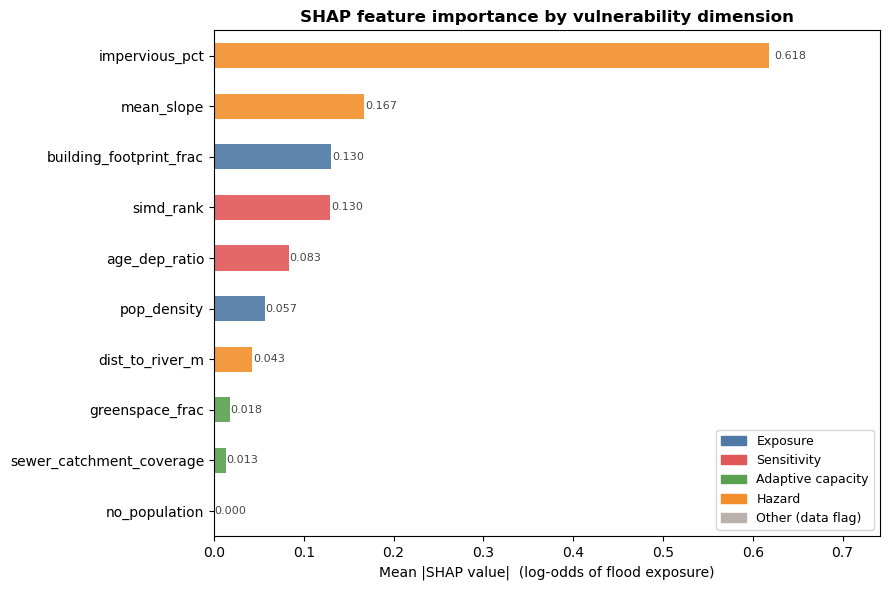

  saved h4_shap_bar_s1_fullsample_1500m.png


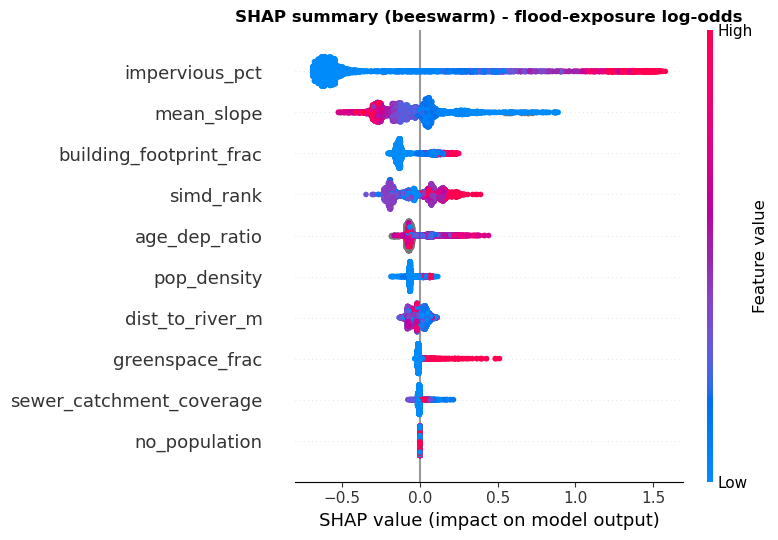

  saved h4_shap_beeswarm_s1_fullsample_1500m.png


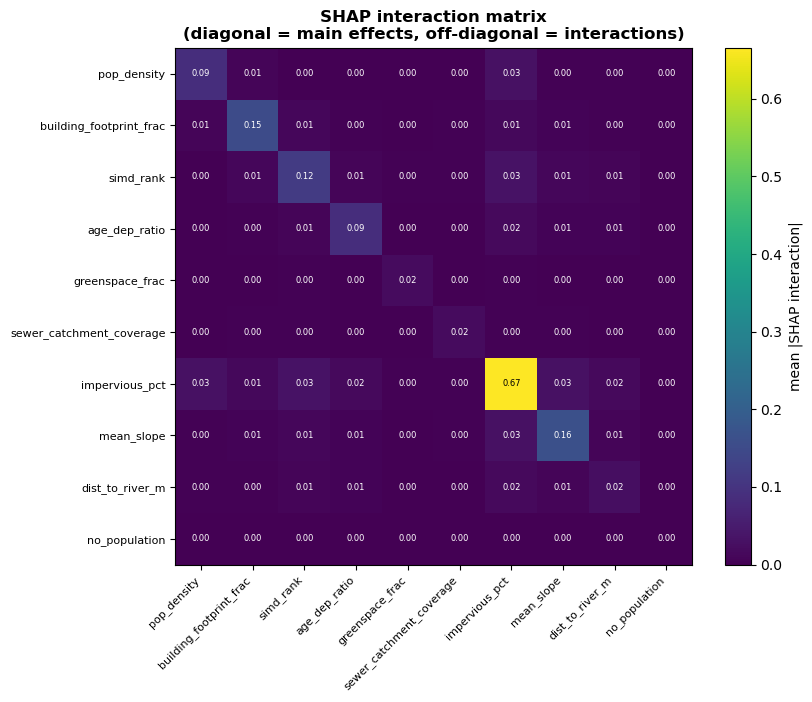

  saved h4_shap_interaction_heatmap_s1_fullsample_1500m.png


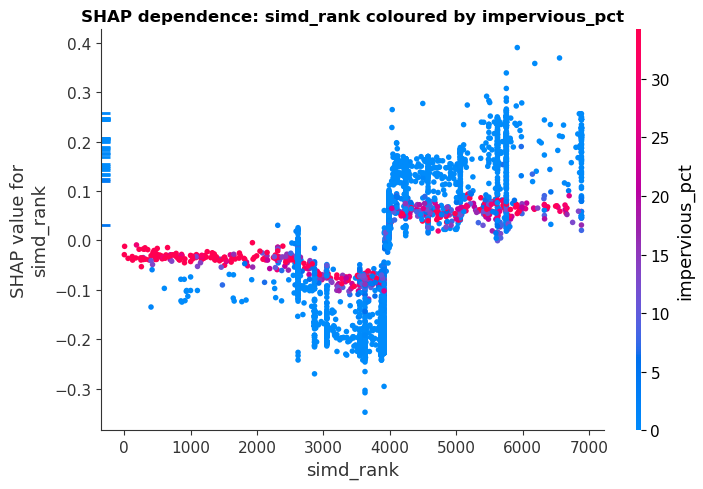

  saved h4_shap_dependence_top_pair_s1_fullsample_1500m.png


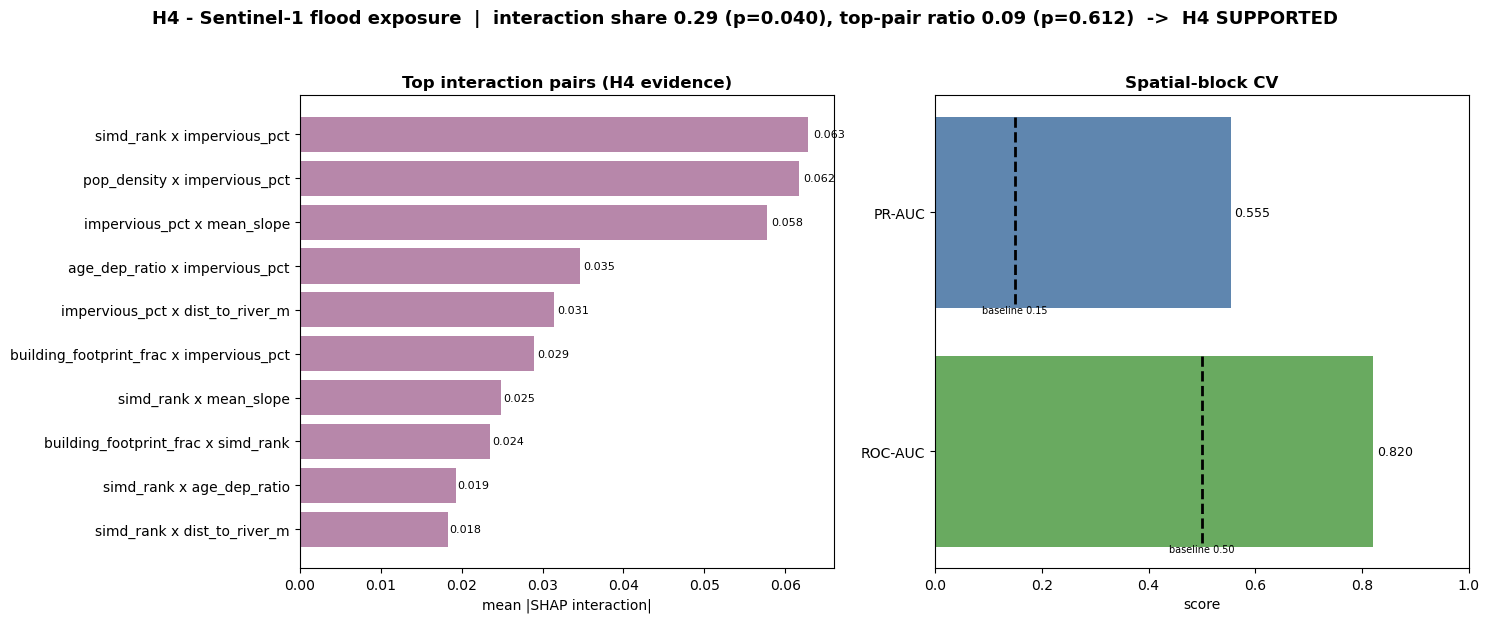

  saved h4_results_summary_s1_fullsample_1500m.png


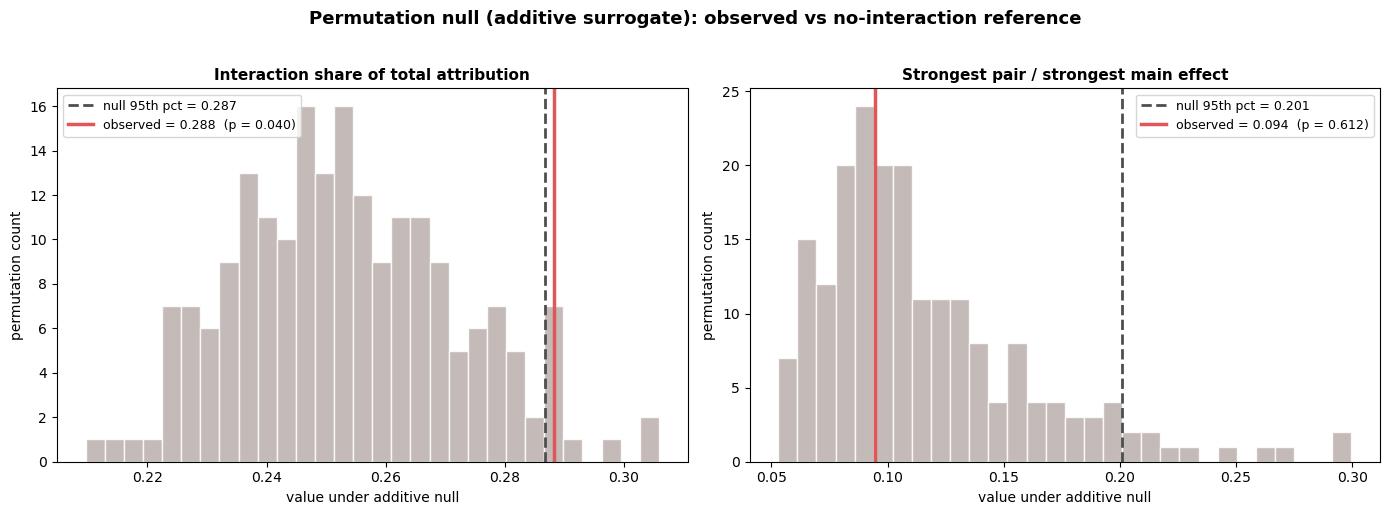

  saved h4_permutation_null_s1_fullsample_1500m.png

Saved report + 6 figures + 2 CSVs + metrics JSON + model  [s1_fullsample_1500m]


In [ ]:
#!/usr/bin/env python3
# Pipeline: full-sample binary exposure (s1_flood_frac > 0) -> XGBoost classifier# 
# (imbalance via scale_pos_weight) -> stratified SPATIAL-BLOCK CV (PR-AUC/ROC-AUC)
# -> final model -> Tree-SHAP main + interaction values -> PERMUTATION NULL that
# provides DATA-DRIVEN significance for the interaction criteria (H4 verdict) -> plots.

#The permutation (surrogate-data) null replaces the hand-picked 0.10 thresholds:
#instead of asking "is the interaction share >= 0.10", it asks "is the observed
#interaction share larger than what this same XGBoost + SHAP pipeline produces when
#the true data-generating process is ADDITIVE (main effects only, no interactions)?"
#This yields an empirical p-value for each criterion and, as a by-product, cancels
#the absolute-value inflation bias because the null carries the identical bias.

#Requires: xgboost>=1.6, shap, scikit-learn>=1.0, geopandas, matplotlib, pandas.


from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
# For a headless terminal / long permutation run, uncomment the next line:
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import xgboost as xgb
import shap


RUN_LABEL  = "s1_fullsample_1500m"     # change per run
HEX_PATH   = Path("hex_h3_res9_joined.gpkg")
TARGET_CRS = "EPSG:3035"
RESP_RAW   = "s1_flood_frac"
BLOCK_M    = 1500
N_SPLITS   = 5
SEED       = 42
SHOW       = True                       # True = display on screen; False = save only

FEATURES = [
    "pop_density", "building_footprint_frac",          # exposure
    "simd_rank", "age_dep_ratio",                      # sensitivity (may be NaN)
    "greenspace_frac", "sewer_catchment_coverage",     # adaptive capacity
    "impervious_pct", "mean_slope", "dist_to_river_m", # hazard
]
DIMENSION = {
    "pop_density":"Exposure", "building_footprint_frac":"Exposure",
    "simd_rank":"Sensitivity", "age_dep_ratio":"Sensitivity",
    "greenspace_frac":"Adaptive capacity", "sewer_catchment_coverage":"Adaptive capacity",
    "impervious_pct":"Hazard", "mean_slope":"Hazard", "dist_to_river_m":"Hazard",
    "no_population":"Other (data flag)",
}
DIM_COLOR = {"Exposure":"#4E79A7", "Sensitivity":"#E15759",
             "Adaptive capacity":"#59A14F", "Hazard":"#F28E2B",
             "Other (data flag)":"#BAB0AC"}

# Interaction criteria 
# These 10% values are retained ONLY as descriptive "materiality floors" for
# continuity with the earlier analysis. The INFERENTIAL verdict is now driven by
# the permutation null below (empirical p-values), not by these constants.
SHARE_MIN = 0.10        # descriptive floor: interactions as share of total SHAP attribution
PAIR_MIN  = 0.10        # descriptive floor: strongest pair / strongest main effect

# Permutation (surrogate-data) null
N_PERM    = 200         # permutations. 100 for a quick pass; 500 for the final run.
PERM_SEED = 1000        # base seed for the null loop
ALPHA     = 0.05        # significance level for the empirical test
GEN_TREES = 300         # depth-1 stumps in the additive null-generating model
# NOTE ON RUNTIME: each permutation refits XGBoost and recomputes SHAP interaction
# values (the slow step, O(n * trees * features^2)). 
# N_PERM=200 on this data. 

OUT_RPT = Path(f"h4_report_{RUN_LABEL}.txt")
rpt = []
def log(m=""):
    print(m); rpt.append(str(m))

def finish(fig_path):
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show() if SHOW else plt.close()
    print(f"  saved {fig_path}")

# Load and response and spatial blocks 
log("=" * 78)
log(f"H4 - XGBoost + SHAP interaction analysis  [{RUN_LABEL}]")
log("=" * 78)
gdf = gpd.read_file(HEX_PATH)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs(TARGET_CRS)
log(f"Loaded {len(gdf):,} hexes")

need = [c for c in FEATURES if c in gdf.columns] + [RESP_RAW]
miss = [c for c in FEATURES + [RESP_RAW] if c not in gdf.columns]
if RESP_RAW not in gdf.columns:
    raise KeyError(f"Response '{RESP_RAW}' not found. Columns: {list(gdf.columns)}")
if miss:
    log(f"[warning] missing feature columns dropped: {miss}")
    FEATURES = [c for c in FEATURES if c in gdf.columns]

# no_population flag (also marks NaN-SIMD hexes); informative for the tree
if "age_dep_ratio" in gdf.columns:
    gdf["no_population"] = gdf["age_dep_ratio"].isna().astype(int)
    if "no_population" not in FEATURES:
        FEATURES.append("no_population")

gdf = gdf[gdf[RESP_RAW].notna()].reset_index(drop=True)
y = (gdf[RESP_RAW] > 0).astype(int).to_numpy()
X = gdf[FEATURES].astype(float)                       # NaN preserved for XGBoost

n_pos, n_neg = int(y.sum()), int((1 - y).sum())
base_rate = float(y.mean())
log(f"Exposure: {n_pos:,} exposed / {n_neg:,} dry  (prevalence {base_rate:.1%})")

cent = gdf.geometry.centroid
block = ((cent.x // BLOCK_M).astype(int).astype(str) + "_" +
         (cent.y // BLOCK_M).astype(int).astype(str)).to_numpy()
log(f"Spatial blocks: {len(np.unique(block)):,} of {BLOCK_M} m")

spw = n_neg / max(n_pos, 1)
log(f"scale_pos_weight = {spw:.2f}")

def make_clf(n_estimators=600, early=True):
    p = dict(n_estimators=n_estimators, learning_rate=0.03, max_depth=4,
             min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
             reg_lambda=2.0, scale_pos_weight=spw, objective="binary:logistic",
             eval_metric="aucpr", tree_method="hist", random_state=SEED, n_jobs=-1)
    if early:
        p["early_stopping_rounds"] = 50
    return xgb.XGBClassifier(**p)

# Helper functions reused by the permutation null
def compute_spw(y_vec):
    npos = int(y_vec.sum()); nneg = int(len(y_vec) - y_vec.sum())
    return nneg / max(npos, 1)

def fit_full_model(X_df, y_vec, n_estimators, seed=SEED, use_spw=True):
    """Fit the SAME depth-4 pipeline as the observed final model (no early stop)."""
    p = dict(n_estimators=n_estimators, learning_rate=0.03, max_depth=4,
             min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
             reg_lambda=2.0,
             scale_pos_weight=(compute_spw(y_vec) if use_spw else 1.0),
             objective="binary:logistic", eval_metric="aucpr",
             tree_method="hist", random_state=seed, n_jobs=-1)
    m = xgb.XGBClassifier(**p)
    m.fit(X_df, y_vec, verbose=False)
    return m

def interaction_metrics(model, X_df):
    """Return (interaction_share, pair_ratio) from a fitted model's SHAP matrix."""
    expl  = shap.TreeExplainer(model)
    inter = expl.shap_interaction_values(X_df)          # (n, f, f)
    am    = np.abs(inter).mean(axis=0)                  # (f, f)
    d     = np.diag(am).copy()
    o     = am.copy(); np.fill_diagonal(o, 0.0)
    share = float(o.sum() / (d.sum() + o.sum()))
    fnum  = am.shape[0]
    prs   = sorted(
        (am[i, j] + am[j, i] for i in range(fnum) for j in range(i + 1, fnum)),
        reverse=True)
    ratio = float(prs[0] / d.max()) if d.max() else 0.0
    return share, ratio

# =Stratified spatial- block cross-validation 
log("\n--- Stratified spatial-block CV ---")
outer = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof = np.full(len(y), np.nan); best_iters = []
for k, (tr, te) in enumerate(outer.split(X, y, groups=block), 1):
    inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + k)
    itr, ival = next(inner.split(X.iloc[tr], y[tr], groups=block[tr]))
    clf = make_clf(early=True)
    clf.fit(X.iloc[tr].iloc[itr], y[tr][itr],
            eval_set=[(X.iloc[tr].iloc[ival], y[tr][ival])], verbose=False)
    best_iters.append(clf.best_iteration)
    oof[te] = clf.predict_proba(X.iloc[te])[:, 1]
    log(f"  fold {k}: n_test={len(te):4d}  best_iter={clf.best_iteration}")

pr_auc  = float(average_precision_score(y, oof))
roc_auc = float(roc_auc_score(y, oof))
log(f"\n  OOF PR-AUC  = {pr_auc:.3f}   (no-skill = prevalence = {base_rate:.3f})")
log(f"  OOF ROC-AUC = {roc_auc:.3f}   (no-skill = 0.500)")
log(f"  PR-AUC lift over baseline: {pr_auc / base_rate:.2f}x")

# Final model on all data (for SHAP)
n_final = max(int(np.mean(best_iters)), 50)
log(f"\n--- Final model on all data (n_estimators={n_final}) ---")
final = make_clf(n_estimators=n_final, early=False)
final.fit(X, y, verbose=False)

#  SHAP main and interaction values  (observed)
log("\n--- SHAP (TreeExplainer, log-odds/margin) ---")
explainer  = shap.TreeExplainer(final)
shap_vals  = explainer.shap_values(X)                # (n, f)
inter      = explainer.shap_interaction_values(X)    # (n, f, f)

abs_mean = np.abs(inter).mean(axis=0)                # (f, f)
diag = np.diag(abs_mean).copy()
off  = abs_mean.copy(); np.fill_diagonal(off, 0.0)
total_main, total_inter = diag.sum(), off.sum()
interaction_share = float(total_inter / (total_main + total_inter))

log("  Main-effect strength (mean |SHAP|):")
for name, v in sorted(zip(FEATURES, diag), key=lambda t: -t[1]):
    log(f"    {name:<26}{v:.4f}")

f = len(FEATURES)
pairs = [(FEATURES[i], FEATURES[j], float(abs_mean[i, j] + abs_mean[j, i]))
         for i in range(f) for j in range(i + 1, f)]
pairs.sort(key=lambda t: -t[2])
log("\n  Top interaction pairs (mean |SHAP interaction|):")
for a, b, v in pairs[:10]:
    log(f"    {a:<24} x {b:<24}{v:.4f}")

strongest_main = float(diag.max())
strongest_pair = pairs[0][2]
pair_ratio = float(strongest_pair / strongest_main) if strongest_main else 0.0

# Permutation (Srrogate-data) Null  -> data-driven significance
# Build an ADDITIVE null-generating model: Depth-1 stumps can only add main
# effects (no interactions are representable). NO scale_pos_weight here, so its
# predicted probabilities stay realistic and simulated prevalence ~= observed.
log("\n--- Permutation null (additive surrogate) ---")
gen = xgb.XGBClassifier(
    n_estimators=GEN_TREES, learning_rate=0.05, max_depth=1,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", random_state=SEED, n_jobs=-1)
gen.fit(X, y, verbose=False)
p_add = gen.predict_proba(X)[:, 1]
log(f"  additive generator: {GEN_TREES} depth-1 stumps, "
    f"mean p_add={p_add.mean():.3f} (obs prevalence={base_rate:.3f})")

rng = np.random.default_rng(PERM_SEED)
null_share = np.empty(N_PERM)
null_ratio = np.empty(N_PERM)
log(f"  running {N_PERM} permutations (this is the slow step) ...")
for b in range(N_PERM):
    # simulate a response with main-effect structure but NO interactions
    y_null = (rng.random(len(p_add)) < p_add).astype(int)
    if y_null.sum() in (0, len(y_null)):                 # guard degenerate draws
        y_null[rng.integers(0, len(y_null))] ^= 1
    m_null = fit_full_model(X, y_null, n_final, seed=SEED + 1 + b, use_spw=True)
    s, r = interaction_metrics(m_null, X)
    null_share[b], null_ratio[b] = s, r
    if (b + 1) % 25 == 0:
        log(f"    perm {b + 1}/{N_PERM}")

# one-sided upper-tail empirical p-values (Davison-Hinkley +1 correction)
p_share = float((1 + np.sum(null_share >= interaction_share)) / (1 + N_PERM))
p_ratio = float((1 + np.sum(null_ratio >= pair_ratio))       / (1 + N_PERM))
thr_share = float(np.quantile(null_share, 1 - ALPHA))         # data-driven 95th pct
thr_ratio = float(np.quantile(null_ratio, 1 - ALPHA))
log(f"  interaction share: obs={interaction_share:.3f}  "
    f"null95={thr_share:.3f}  p={p_share:.3f}")
log(f"  pair ratio:        obs={pair_ratio:.3f}  "
    f"null95={thr_ratio:.3f}  p={p_ratio:.3f}")

#  H4 VERDICT  (inferential = permutation; floors = descriptive)

share_sig = bool(p_share < ALPHA)     # PRIMARY: do interactions exceed the additive null?
ratio_sig = bool(p_ratio < ALPHA)     # SECONDARY: is the top pair concentrated beyond null?
supported = share_sig                 # hypothesis is an existence claim -> driven by share

log("\n" + "=" * 78)
log("H4 CRITERION  (data-driven permutation null; floors shown for reference)")
log(f"  [1] interaction share = {interaction_share:.3f}  "
    f"vs null95={thr_share:.3f}  p={p_share:.3f}  "
    f"-> {'SIGNIFICANT' if share_sig else 'n.s.'}  (floor {SHARE_MIN})")
log(f"  [2] strongest-pair ratio = {pair_ratio:.3f}  "
    f"vs null95={thr_ratio:.3f}  p={p_ratio:.3f}  "
    f"-> {'SIGNIFICANT' if ratio_sig else 'n.s.'}  (floor {PAIR_MIN})")
log(f"  strongest pair: {pairs[0][0]} x {pairs[0][1]}")
log(f"  => H4 (interaction existence) {'SUPPORTED' if supported else 'NOT SUPPORTED'}"
    f"  |  concentration {'supported' if ratio_sig else 'not supported'}")
log("=" * 78)

# Plots
# A. SHAP importance bar, coloured by vulnerability dimension
mean_abs = pd.Series(np.abs(shap_vals).mean(0), index=FEATURES).sort_values()
colors = [DIM_COLOR[DIMENSION.get(fn, "Other (data flag)")] for fn in mean_abs.index]
fig, ax = plt.subplots(figsize=(9, 6))
mean_abs.plot(kind="barh", ax=ax, color=colors, alpha=0.9)
for p, v in zip(ax.patches, mean_abs.values):
    ax.text(p.get_width() * 1.01, p.get_y() + p.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=8, color="#444")
ax.set_xlim(0, mean_abs.max() * 1.2)
ax.set_xlabel("Mean |SHAP value|  (log-odds of flood exposure)")
ax.set_title("SHAP feature importance by vulnerability dimension", fontweight="bold")
present = [d for d in DIM_COLOR if d in {DIMENSION.get(fn) for fn in FEATURES}]
ax.legend(handles=[mpatches.Patch(color=DIM_COLOR[d], label=d) for d in present],
          loc="lower right", fontsize=9)
finish(f"h4_shap_bar_{RUN_LABEL}.png")

# B. Beeswarm (direction + distribution -> non-linearity evidence)
shap.summary_plot(shap_vals, X, feature_names=FEATURES, show=False)
plt.title("SHAP summary (beeswarm) - flood-exposure log-odds", fontweight="bold")
finish(f"h4_shap_beeswarm_{RUN_LABEL}.png")

# C. Interaction heatmap (diagonal = main effects, off = interactions)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(abs_mean, cmap="viridis")
ax.set_xticks(range(f)); ax.set_yticks(range(f))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(f):
    for j in range(f):
        ax.text(j, i, f"{abs_mean[i, j]:.2f}", ha="center", va="center",
                color="white" if abs_mean[i, j] < abs_mean.max() * 0.6 else "black",
                fontsize=6)
fig.colorbar(im, ax=ax, label="mean |SHAP interaction|")
ax.set_title("SHAP interaction matrix\n(diagonal = main effects, off-diagonal = interactions)",
             fontweight="bold")
finish(f"h4_shap_interaction_heatmap_{RUN_LABEL}.png")

# D. Dependence plot of the strongest pair, coloured by its partner (THE H4 plot)
top_a, top_b, _ = pairs[0]
try:
    shap.dependence_plot(top_a, shap_vals, X, interaction_index=top_b, show=False)
    plt.title(f"SHAP dependence: {top_a} coloured by {top_b}", fontweight="bold")
    finish(f"h4_shap_dependence_top_pair_{RUN_LABEL}.png")
except Exception as e:
    print(f"  [dependence plot skipped: {e}]")

# E. Combined summary panel: top interactions + CV performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
pdf = pd.DataFrame(pairs[:10], columns=["a", "b", "s"]).assign(
    pair=lambda d: d.a + " x " + d.b).sort_values("s")
axes[0].barh(pdf["pair"], pdf["s"], color="#B07AA1", alpha=0.9)
for i, v in enumerate(pdf["s"]):
    axes[0].text(v * 1.01, i, f"{v:.3f}", va="center", fontsize=8)
axes[0].set_xlabel("mean |SHAP interaction|")
axes[0].set_title("Top interaction pairs (H4 evidence)", fontweight="bold")
cv = pd.DataFrame({"m": ["PR-AUC", "ROC-AUC"], "s": [pr_auc, roc_auc], "b": [base_rate, 0.5]})
axes[1].barh(cv["m"], cv["s"], color=["#4E79A7", "#59A14F"], alpha=0.9)
axes[1].set_xlim(0, 1)
for i, (s, b) in enumerate(zip(cv["s"], cv["b"])):
    axes[1].text(s * 1.01, i, f"{s:.3f}", va="center", fontsize=9)
    axes[1].plot([b, b], [i - 0.4, i + 0.4], "k--", lw=2)
    axes[1].text(b, i + 0.42, f"baseline {b:.2f}", ha="center", fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlabel("score"); axes[1].set_title("Spatial-block CV", fontweight="bold")
verdict = "SUPPORTED" if supported else "NOT SUPPORTED"
plt.suptitle(f"H4 - Sentinel-1 flood exposure  |  interaction share {interaction_share:.2f} "
             f"(p={p_share:.3f}), top-pair ratio {pair_ratio:.2f} (p={p_ratio:.3f})  ->  "
             f"H4 {verdict}",
             fontsize=13, fontweight="bold", y=1.03)
finish(f"h4_results_summary_{RUN_LABEL}.png")

# F. Permutation null distributions with observed values marked (THE new figure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_, nd, obs, thr, pval, name in [
    (axes[0], null_share, interaction_share, thr_share, p_share, "Interaction share of total attribution"),
    (axes[1], null_ratio, pair_ratio,        thr_ratio, p_ratio, "Strongest pair / strongest main effect"),
]:
    ax_.hist(nd, bins=30, color="#BAB0AC", alpha=0.85, edgecolor="white")
    ax_.axvline(thr, color="#4E4E4E", ls="--", lw=2,
                label=f"null 95th pct = {thr:.3f}")
    ax_.axvline(obs, color="#E15759", lw=2.5,
                label=f"observed = {obs:.3f}  (p = {pval:.3f})")
    ax_.set_title(name, fontweight="bold", fontsize=11)
    ax_.set_xlabel("value under additive null")
    ax_.set_ylabel("permutation count")
    ax_.legend(fontsize=9)
plt.suptitle("Permutation null (additive surrogate): observed vs no-interaction reference",
             fontsize=13, fontweight="bold", y=1.02)
finish(f"h4_permutation_null_{RUN_LABEL}.png")

# Save 
pd.DataFrame(pairs, columns=["feature_a", "feature_b", "interaction_strength"]) \
  .to_csv(f"h4_interaction_ranking_{RUN_LABEL}.csv", index=False)
pd.DataFrame({"null_share": null_share, "null_ratio": null_ratio}) \
  .to_csv(f"h4_permutation_null_{RUN_LABEL}.csv", index=False)
final.save_model(f"h4_xgb_model_{RUN_LABEL}.json")
json.dump({"run": RUN_LABEL, "pr_auc": pr_auc, "roc_auc": roc_auc,
           "prevalence": base_rate,
           "interaction_share": interaction_share, "pair_ratio": pair_ratio,
           "n_perm": N_PERM,
           "null95_share": thr_share, "null95_ratio": thr_ratio,
           "p_share": p_share, "p_ratio": p_ratio,
           "share_significant": share_sig, "ratio_significant": ratio_sig,
           "h4_supported": supported,
           "strongest_pair": [str(pairs[0][0]), str(pairs[0][1])]},
          open(f"h4_metrics_{RUN_LABEL}.json", "w"), indent=2)
Path(OUT_RPT).write_text("\n".join(rpt))
log(f"\nSaved report + 6 figures + 2 CSVs + metrics JSON + model  [{RUN_LABEL}]")

## Option: Permutation (surrogate-data) null 
N_PERM    = 1000       # permutations. 100 for a quick pass; 500 for the final run.

H4 - XGBoost + SHAP interaction analysis  [s1_fullsample_1500m]
Loaded 4,201 hexes
Exposure: 627 exposed / 3,574 dry  (prevalence 14.9%)
Spatial blocks: 232 of 1500 m
scale_pos_weight = 5.70

--- Stratified spatial-block CV ---
  fold 1: n_test= 762  best_iter=30
  fold 2: n_test= 867  best_iter=24
  fold 3: n_test=1069  best_iter=56
  fold 4: n_test= 723  best_iter=17
  fold 5: n_test= 780  best_iter=57

  OOF PR-AUC  = 0.555   (no-skill = prevalence = 0.149)
  OOF ROC-AUC = 0.820   (no-skill = 0.500)
  PR-AUC lift over baseline: 3.72x

--- Final model on all data (n_estimators=50) ---

--- SHAP (TreeExplainer, log-odds/margin) ---
  Main-effect strength (mean |SHAP|):
    impervious_pct            0.6658
    mean_slope                0.1624
    building_footprint_frac   0.1511
    simd_rank                 0.1154
    pop_density               0.0869
    age_dep_ratio             0.0867
    dist_to_river_m           0.0242
    greenspace_frac           0.0198
    sewer_catchment_cover

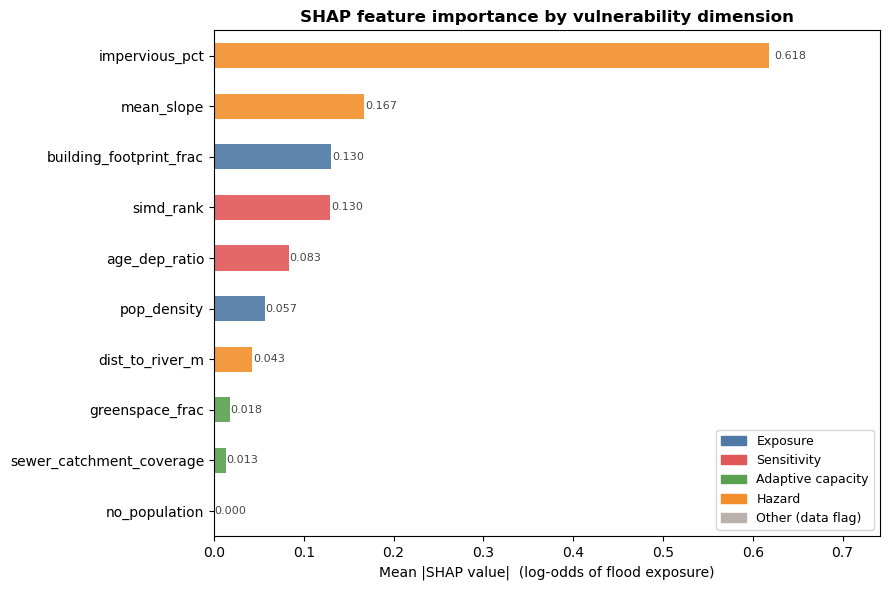

  saved h4_shap_bar_s1_fullsample_1500m.png


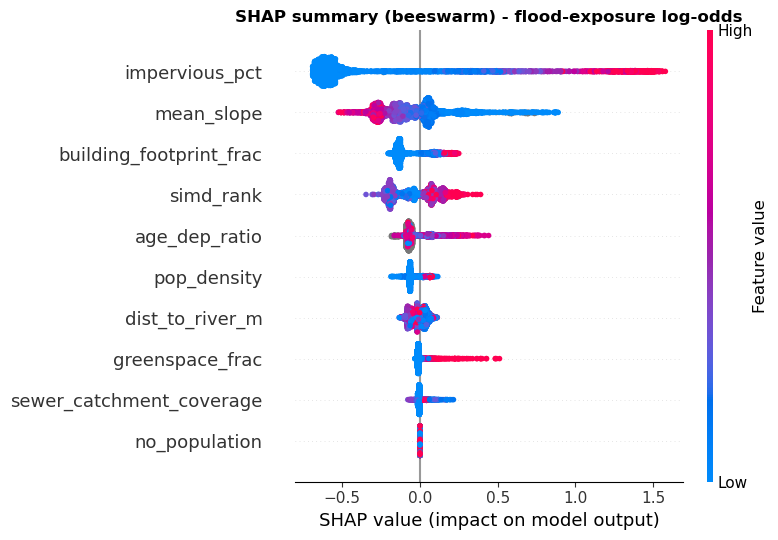

  saved h4_shap_beeswarm_s1_fullsample_1500m.png


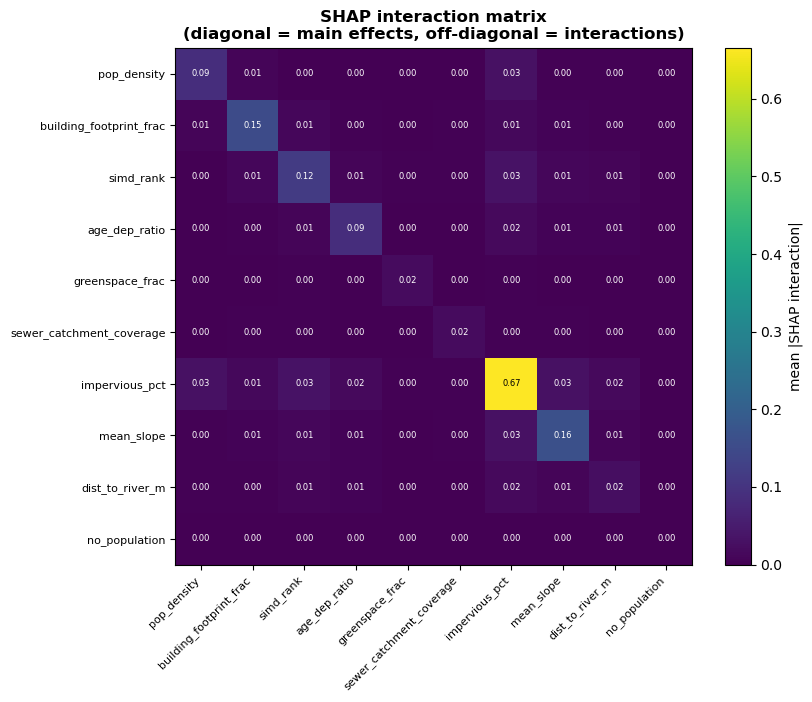

  saved h4_shap_interaction_heatmap_s1_fullsample_1500m.png


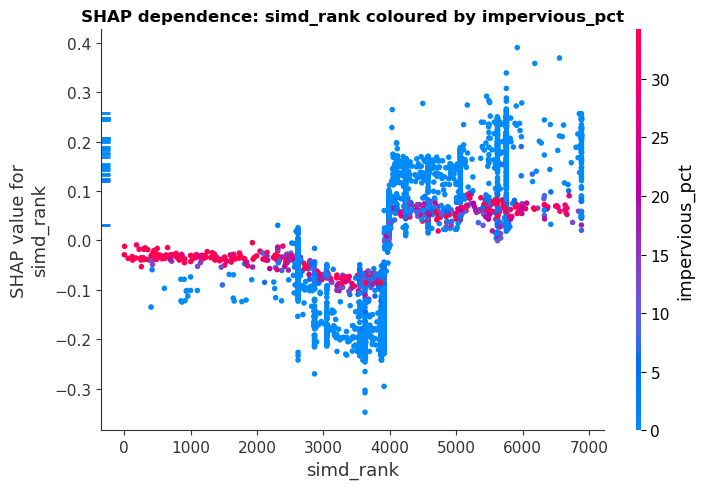

  saved h4_shap_dependence_top_pair_s1_fullsample_1500m.png


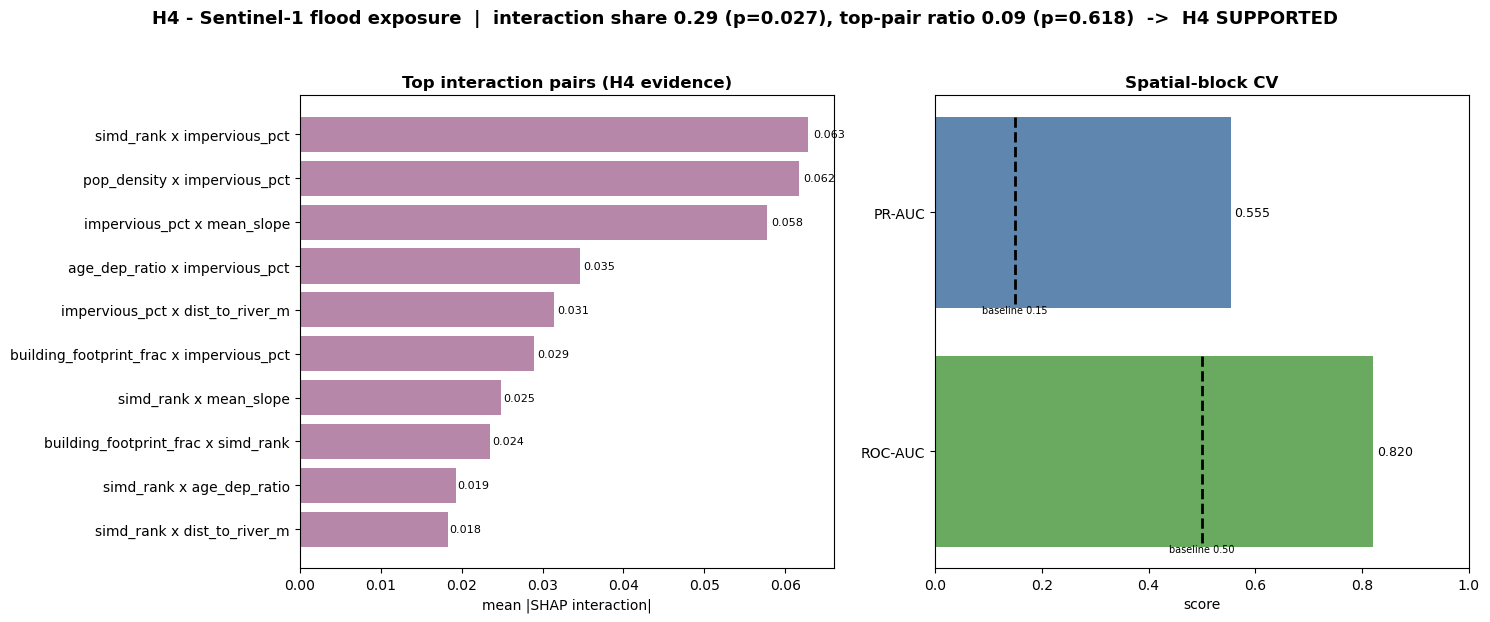

  saved h4_results_summary_s1_fullsample_1500m.png


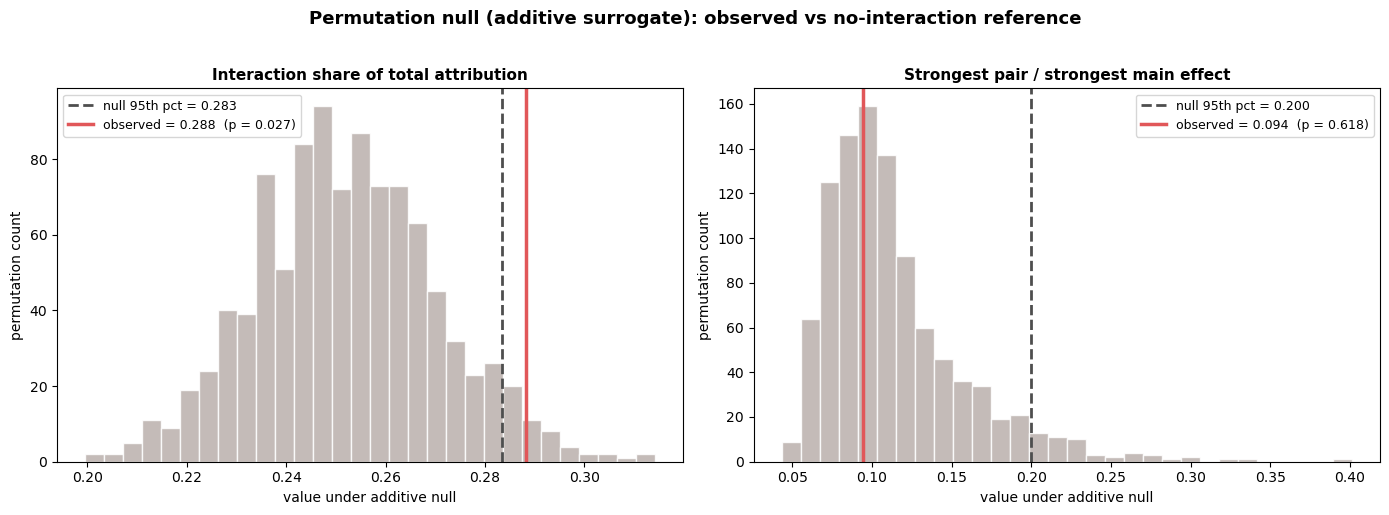

  saved h4_permutation_null_s1_fullsample_1500m.png

Saved report + 6 figures + 2 CSVs + metrics JSON + model  [s1_fullsample_1500m]


In [ ]:
#!/usr/bin/env python3

from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
# For a headless terminal / long permutation run, uncomment the next line:
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import xgboost as xgb
import shap

RUN_LABEL  = "s1_fullsample_1500m"     # change per run
HEX_PATH   = Path("hex_h3_res9_joined.gpkg")
TARGET_CRS = "EPSG:3035"
RESP_RAW   = "s1_flood_frac"
BLOCK_M    = 1500
N_SPLITS   = 5
SEED       = 42
SHOW       = True                       # True = display on screen; False = save only

FEATURES = [
    "pop_density", "building_footprint_frac",          # exposure
    "simd_rank", "age_dep_ratio",                      # sensitivity (may be NaN)
    "greenspace_frac", "sewer_catchment_coverage",     # adaptive capacity
    "impervious_pct", "mean_slope", "dist_to_river_m", # hazard
]
DIMENSION = {
    "pop_density":"Exposure", "building_footprint_frac":"Exposure",
    "simd_rank":"Sensitivity", "age_dep_ratio":"Sensitivity",
    "greenspace_frac":"Adaptive capacity", "sewer_catchment_coverage":"Adaptive capacity",
    "impervious_pct":"Hazard", "mean_slope":"Hazard", "dist_to_river_m":"Hazard",
    "no_population":"Other (data flag)",
}
DIM_COLOR = {"Exposure":"#4E79A7", "Sensitivity":"#E15759",
             "Adaptive capacity":"#59A14F", "Hazard":"#F28E2B",
             "Other (data flag)":"#BAB0AC"}


SHARE_MIN = 0.10        # descriptive floor: interactions as share of total SHAP attribution
PAIR_MIN  = 0.10        # descriptive floor: strongest pair / strongest main effect

# Permutation (surrogate-data) null
N_PERM    = 1000       # permutations. 100 for a quick pass; 500 for the final run.
PERM_SEED = 1000        # base seed for the null loop
ALPHA     = 0.05        # significance level for the empirical test
GEN_TREES = 300         # depth-1 stumps in the additive null-generating model


OUT_RPT = Path(f"h4_report_{RUN_LABEL}.txt")
rpt = []
def log(m=""):
    print(m); rpt.append(str(m))

def finish(fig_path):
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show() if SHOW else plt.close()
    print(f"  saved {fig_path}")


log("=" * 78)
log(f"H4 - XGBoost + SHAP interaction analysis  [{RUN_LABEL}]")
log("=" * 78)
gdf = gpd.read_file(HEX_PATH)
if gdf.crs is None or gdf.crs.to_epsg() != 3035:
    gdf = gdf.to_crs(TARGET_CRS)
log(f"Loaded {len(gdf):,} hexes")

need = [c for c in FEATURES if c in gdf.columns] + [RESP_RAW]
miss = [c for c in FEATURES + [RESP_RAW] if c not in gdf.columns]
if RESP_RAW not in gdf.columns:
    raise KeyError(f"Response '{RESP_RAW}' not found. Columns: {list(gdf.columns)}")
if miss:
    log(f"[warning] missing feature columns dropped: {miss}")
    FEATURES = [c for c in FEATURES if c in gdf.columns]

# no_population flag (also marks NaN-SIMD hexes); informative for the tree
if "age_dep_ratio" in gdf.columns:
    gdf["no_population"] = gdf["age_dep_ratio"].isna().astype(int)
    if "no_population" not in FEATURES:
        FEATURES.append("no_population")

gdf = gdf[gdf[RESP_RAW].notna()].reset_index(drop=True)
y = (gdf[RESP_RAW] > 0).astype(int).to_numpy()
X = gdf[FEATURES].astype(float)                       # NaN preserved for XGBoost

n_pos, n_neg = int(y.sum()), int((1 - y).sum())
base_rate = float(y.mean())
log(f"Exposure: {n_pos:,} exposed / {n_neg:,} dry  (prevalence {base_rate:.1%})")

cent = gdf.geometry.centroid
block = ((cent.x // BLOCK_M).astype(int).astype(str) + "_" +
         (cent.y // BLOCK_M).astype(int).astype(str)).to_numpy()
log(f"Spatial blocks: {len(np.unique(block)):,} of {BLOCK_M} m")

spw = n_neg / max(n_pos, 1)
log(f"scale_pos_weight = {spw:.2f}")

def make_clf(n_estimators=600, early=True):
    p = dict(n_estimators=n_estimators, learning_rate=0.03, max_depth=4,
             min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
             reg_lambda=2.0, scale_pos_weight=spw, objective="binary:logistic",
             eval_metric="aucpr", tree_method="hist", random_state=SEED, n_jobs=-1)
    if early:
        p["early_stopping_rounds"] = 50
    return xgb.XGBClassifier(**p)


def compute_spw(y_vec):
    npos = int(y_vec.sum()); nneg = int(len(y_vec) - y_vec.sum())
    return nneg / max(npos, 1)

def fit_full_model(X_df, y_vec, n_estimators, seed=SEED, use_spw=True):
    """Fit the SAME depth-4 pipeline as the observed final model (no early stop)."""
    p = dict(n_estimators=n_estimators, learning_rate=0.03, max_depth=4,
             min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
             reg_lambda=2.0,
             scale_pos_weight=(compute_spw(y_vec) if use_spw else 1.0),
             objective="binary:logistic", eval_metric="aucpr",
             tree_method="hist", random_state=seed, n_jobs=-1)
    m = xgb.XGBClassifier(**p)
    m.fit(X_df, y_vec, verbose=False)
    return m

def interaction_metrics(model, X_df):
    """Return (interaction_share, pair_ratio) from a fitted model's SHAP matrix."""
    expl  = shap.TreeExplainer(model)
    inter = expl.shap_interaction_values(X_df)          # (n, f, f)
    am    = np.abs(inter).mean(axis=0)                  # (f, f)
    d     = np.diag(am).copy()
    o     = am.copy(); np.fill_diagonal(o, 0.0)
    share = float(o.sum() / (d.sum() + o.sum()))
    fnum  = am.shape[0]
    prs   = sorted(
        (am[i, j] + am[j, i] for i in range(fnum) for j in range(i + 1, fnum)),
        reverse=True)
    ratio = float(prs[0] / d.max()) if d.max() else 0.0
    return share, ratio


log("\n--- Stratified spatial-block CV ---")
outer = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof = np.full(len(y), np.nan); best_iters = []
for k, (tr, te) in enumerate(outer.split(X, y, groups=block), 1):
    inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + k)
    itr, ival = next(inner.split(X.iloc[tr], y[tr], groups=block[tr]))
    clf = make_clf(early=True)
    clf.fit(X.iloc[tr].iloc[itr], y[tr][itr],
            eval_set=[(X.iloc[tr].iloc[ival], y[tr][ival])], verbose=False)
    best_iters.append(clf.best_iteration)
    oof[te] = clf.predict_proba(X.iloc[te])[:, 1]
    log(f"  fold {k}: n_test={len(te):4d}  best_iter={clf.best_iteration}")

pr_auc  = float(average_precision_score(y, oof))
roc_auc = float(roc_auc_score(y, oof))
log(f"\n  OOF PR-AUC  = {pr_auc:.3f}   (no-skill = prevalence = {base_rate:.3f})")
log(f"  OOF ROC-AUC = {roc_auc:.3f}   (no-skill = 0.500)")
log(f"  PR-AUC lift over baseline: {pr_auc / base_rate:.2f}x")


n_final = max(int(np.mean(best_iters)), 50)
log(f"\n--- Final model on all data (n_estimators={n_final}) ---")
final = make_clf(n_estimators=n_final, early=False)
final.fit(X, y, verbose=False)


log("\n--- SHAP (TreeExplainer, log-odds/margin) ---")
explainer  = shap.TreeExplainer(final)
shap_vals  = explainer.shap_values(X)                # (n, f)
inter      = explainer.shap_interaction_values(X)    # (n, f, f)

abs_mean = np.abs(inter).mean(axis=0)                # (f, f)
diag = np.diag(abs_mean).copy()
off  = abs_mean.copy(); np.fill_diagonal(off, 0.0)
total_main, total_inter = diag.sum(), off.sum()
interaction_share = float(total_inter / (total_main + total_inter))

log("  Main-effect strength (mean |SHAP|):")
for name, v in sorted(zip(FEATURES, diag), key=lambda t: -t[1]):
    log(f"    {name:<26}{v:.4f}")

f = len(FEATURES)
pairs = [(FEATURES[i], FEATURES[j], float(abs_mean[i, j] + abs_mean[j, i]))
         for i in range(f) for j in range(i + 1, f)]
pairs.sort(key=lambda t: -t[2])
log("\n  Top interaction pairs (mean |SHAP interaction|):")
for a, b, v in pairs[:10]:
    log(f"    {a:<24} x {b:<24}{v:.4f}")

strongest_main = float(diag.max())
strongest_pair = pairs[0][2]
pair_ratio = float(strongest_pair / strongest_main) if strongest_main else 0.0


log("\n--- Permutation null (additive surrogate) ---")
gen = xgb.XGBClassifier(
    n_estimators=GEN_TREES, learning_rate=0.05, max_depth=1,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", random_state=SEED, n_jobs=-1)
gen.fit(X, y, verbose=False)
p_add = gen.predict_proba(X)[:, 1]
log(f"  additive generator: {GEN_TREES} depth-1 stumps, "
    f"mean p_add={p_add.mean():.3f} (obs prevalence={base_rate:.3f})")

rng = np.random.default_rng(PERM_SEED)
null_share = np.empty(N_PERM)
null_ratio = np.empty(N_PERM)
log(f"  running {N_PERM} permutations (this is the slow step) ...")
for b in range(N_PERM):
    # simulate a response with main-effect structure but NO interactions
    y_null = (rng.random(len(p_add)) < p_add).astype(int)
    if y_null.sum() in (0, len(y_null)):                 # guard degenerate draws
        y_null[rng.integers(0, len(y_null))] ^= 1
    m_null = fit_full_model(X, y_null, n_final, seed=SEED + 1 + b, use_spw=True)
    s, r = interaction_metrics(m_null, X)
    null_share[b], null_ratio[b] = s, r
    if (b + 1) % 25 == 0:
        log(f"    perm {b + 1}/{N_PERM}")

# one-sided upper-tail empirical p-values (Davison-Hinkley +1 correction)
p_share = float((1 + np.sum(null_share >= interaction_share)) / (1 + N_PERM))
p_ratio = float((1 + np.sum(null_ratio >= pair_ratio))       / (1 + N_PERM))
thr_share = float(np.quantile(null_share, 1 - ALPHA))         # data-driven 95th pct
thr_ratio = float(np.quantile(null_ratio, 1 - ALPHA))
log(f"  interaction share: obs={interaction_share:.3f}  "
    f"null95={thr_share:.3f}  p={p_share:.3f}")
log(f"  pair ratio:        obs={pair_ratio:.3f}  "
    f"null95={thr_ratio:.3f}  p={p_ratio:.3f}")

share_sig = bool(p_share < ALPHA)     # PRIMARY: do interactions exceed the additive null?
ratio_sig = bool(p_ratio < ALPHA)     # SECONDARY: is the top pair concentrated beyond null?
supported = share_sig                 # hypothesis is an existence claim -> driven by share

log("\n" + "=" * 78)
log("H4 CRITERION  (data-driven permutation null; floors shown for reference)")
log(f"  [1] interaction share = {interaction_share:.3f}  "
    f"vs null95={thr_share:.3f}  p={p_share:.3f}  "
    f"-> {'SIGNIFICANT' if share_sig else 'n.s.'}  (floor {SHARE_MIN})")
log(f"  [2] strongest-pair ratio = {pair_ratio:.3f}  "
    f"vs null95={thr_ratio:.3f}  p={p_ratio:.3f}  "
    f"-> {'SIGNIFICANT' if ratio_sig else 'n.s.'}  (floor {PAIR_MIN})")
log(f"  strongest pair: {pairs[0][0]} x {pairs[0][1]}")
log(f"  => H4 (interaction existence) {'SUPPORTED' if supported else 'NOT SUPPORTED'}"
    f"  |  concentration {'supported' if ratio_sig else 'not supported'}")
log("=" * 78)

# Plots

# A. SHAP importance bar, coloured by vulnerability dimension
mean_abs = pd.Series(np.abs(shap_vals).mean(0), index=FEATURES).sort_values()
colors = [DIM_COLOR[DIMENSION.get(fn, "Other (data flag)")] for fn in mean_abs.index]
fig, ax = plt.subplots(figsize=(9, 6))
mean_abs.plot(kind="barh", ax=ax, color=colors, alpha=0.9)
for p, v in zip(ax.patches, mean_abs.values):
    ax.text(p.get_width() * 1.01, p.get_y() + p.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=8, color="#444")
ax.set_xlim(0, mean_abs.max() * 1.2)
ax.set_xlabel("Mean |SHAP value|  (log-odds of flood exposure)")
ax.set_title("SHAP feature importance by vulnerability dimension", fontweight="bold")
present = [d for d in DIM_COLOR if d in {DIMENSION.get(fn) for fn in FEATURES}]
ax.legend(handles=[mpatches.Patch(color=DIM_COLOR[d], label=d) for d in present],
          loc="lower right", fontsize=9)
finish(f"h4_shap_bar_{RUN_LABEL}.png")

# B. Beeswarm (direction + distribution -> non-linearity evidence)
shap.summary_plot(shap_vals, X, feature_names=FEATURES, show=False)
plt.title("SHAP summary (beeswarm) - flood-exposure log-odds", fontweight="bold")
finish(f"h4_shap_beeswarm_{RUN_LABEL}.png")

# C. Interaction heatmap (diagonal = main effects, off = interactions)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(abs_mean, cmap="viridis")
ax.set_xticks(range(f)); ax.set_yticks(range(f))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(f):
    for j in range(f):
        ax.text(j, i, f"{abs_mean[i, j]:.2f}", ha="center", va="center",
                color="white" if abs_mean[i, j] < abs_mean.max() * 0.6 else "black",
                fontsize=6)
fig.colorbar(im, ax=ax, label="mean |SHAP interaction|")
ax.set_title("SHAP interaction matrix\n(diagonal = main effects, off-diagonal = interactions)",
             fontweight="bold")
finish(f"h4_shap_interaction_heatmap_{RUN_LABEL}.png")

# D. Dependence plot of the strongest pair, coloured by its partner (THE H4 plot)
top_a, top_b, _ = pairs[0]
try:
    shap.dependence_plot(top_a, shap_vals, X, interaction_index=top_b, show=False)
    plt.title(f"SHAP dependence: {top_a} coloured by {top_b}", fontweight="bold")
    finish(f"h4_shap_dependence_top_pair_{RUN_LABEL}.png")
except Exception as e:
    print(f"  [dependence plot skipped: {e}]")

# E. Combined summary panel: top interactions + CV performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
pdf = pd.DataFrame(pairs[:10], columns=["a", "b", "s"]).assign(
    pair=lambda d: d.a + " x " + d.b).sort_values("s")
axes[0].barh(pdf["pair"], pdf["s"], color="#B07AA1", alpha=0.9)
for i, v in enumerate(pdf["s"]):
    axes[0].text(v * 1.01, i, f"{v:.3f}", va="center", fontsize=8)
axes[0].set_xlabel("mean |SHAP interaction|")
axes[0].set_title("Top interaction pairs (H4 evidence)", fontweight="bold")
cv = pd.DataFrame({"m": ["PR-AUC", "ROC-AUC"], "s": [pr_auc, roc_auc], "b": [base_rate, 0.5]})
axes[1].barh(cv["m"], cv["s"], color=["#4E79A7", "#59A14F"], alpha=0.9)
axes[1].set_xlim(0, 1)
for i, (s, b) in enumerate(zip(cv["s"], cv["b"])):
    axes[1].text(s * 1.01, i, f"{s:.3f}", va="center", fontsize=9)
    axes[1].plot([b, b], [i - 0.4, i + 0.4], "k--", lw=2)
    axes[1].text(b, i + 0.42, f"baseline {b:.2f}", ha="center", fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlabel("score"); axes[1].set_title("Spatial-block CV", fontweight="bold")
verdict = "SUPPORTED" if supported else "NOT SUPPORTED"
plt.suptitle(f"H4 - Sentinel-1 flood exposure  |  interaction share {interaction_share:.2f} "
             f"(p={p_share:.3f}), top-pair ratio {pair_ratio:.2f} (p={p_ratio:.3f})  ->  "
             f"H4 {verdict}",
             fontsize=13, fontweight="bold", y=1.03)
finish(f"h4_results_summary_{RUN_LABEL}.png")

# F. Permutation null distributions with observed values marked 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_, nd, obs, thr, pval, name in [
    (axes[0], null_share, interaction_share, thr_share, p_share, "Interaction share of total attribution"),
    (axes[1], null_ratio, pair_ratio,        thr_ratio, p_ratio, "Strongest pair / strongest main effect"),
]:
    ax_.hist(nd, bins=30, color="#BAB0AC", alpha=0.85, edgecolor="white")
    ax_.axvline(thr, color="#4E4E4E", ls="--", lw=2,
                label=f"null 95th pct = {thr:.3f}")
    ax_.axvline(obs, color="#E15759", lw=2.5,
                label=f"observed = {obs:.3f}  (p = {pval:.3f})")
    ax_.set_title(name, fontweight="bold", fontsize=11)
    ax_.set_xlabel("value under additive null")
    ax_.set_ylabel("permutation count")
    ax_.legend(fontsize=9)
plt.suptitle("Permutation null (additive surrogate): Observed vs no-interaction reference",
             fontsize=13, fontweight="bold", y=1.02)
finish(f"h4_permutation_null_{RUN_LABEL}.png")

pd.DataFrame(pairs, columns=["feature_a", "feature_b", "interaction_strength"]) \
  .to_csv(f"h4_interaction_ranking_{RUN_LABEL}.csv", index=False)
pd.DataFrame({"null_share": null_share, "null_ratio": null_ratio}) \
  .to_csv(f"h4_permutation_null_{RUN_LABEL}.csv", index=False)
final.save_model(f"h4_xgb_model_{RUN_LABEL}.json")
json.dump({"run": RUN_LABEL, "pr_auc": pr_auc, "roc_auc": roc_auc,
           "prevalence": base_rate,
           "interaction_share": interaction_share, "pair_ratio": pair_ratio,
           "n_perm": N_PERM,
           "null95_share": thr_share, "null95_ratio": thr_ratio,
           "p_share": p_share, "p_ratio": p_ratio,
           "share_significant": share_sig, "ratio_significant": ratio_sig,
           "h4_supported": supported,
           "strongest_pair": [str(pairs[0][0]), str(pairs[0][1])]},
          open(f"h4_metrics_{RUN_LABEL}.json", "w"), indent=2)
Path(OUT_RPT).write_text("\n".join(rpt))
log(f"\nSaved report + 6 figures + 2 CSVs + metrics JSON + model  [{RUN_LABEL}]")

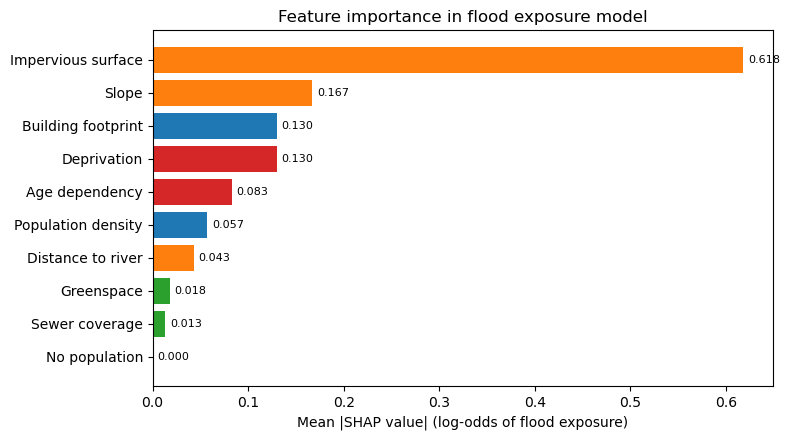

In [ ]:
import matplotlib.pyplot as plt

# Example values 
features = [
    "Impervious surface", "Slope", "Building footprint", "Deprivation",
    "Age dependency", "Population density", "Distance to river",
    "Greenspace", "Sewer coverage", "No population"
]
values = [0.618, 0.167, 0.130, 0.130, 0.083, 0.057, 0.043, 0.018, 0.013, 0.000]

colors = [
    "tab:orange", "tab:orange", "tab:blue", "tab:red", "tab:red",
    "tab:blue", "tab:orange", "tab:green", "tab:green", "0.7"
]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = range(len(features))

ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(features)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (log-odds of flood exposure)")
ax.set_title("Feature importance in flood exposure model")

for i, v in enumerate(values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

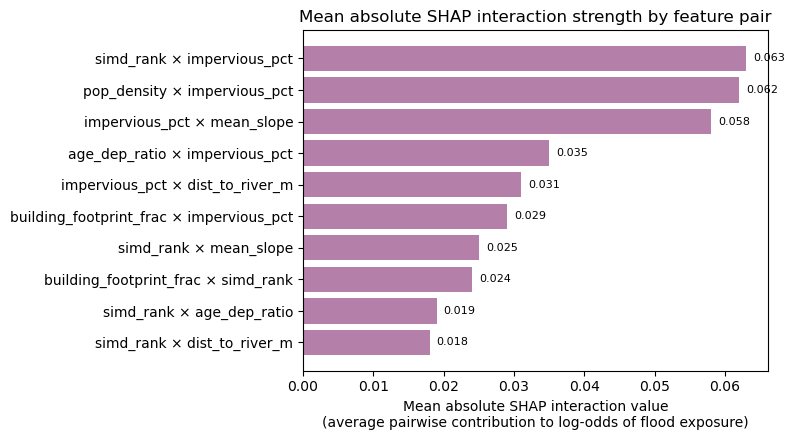

In [ ]:
import matplotlib.pyplot as plt

pairs = [
    "simd_rank × impervious_pct",
    "pop_density × impervious_pct",
    "impervious_pct × mean_slope",
    "age_dep_ratio × impervious_pct",
    "impervious_pct × dist_to_river_m",
    "building_footprint_frac × impervious_pct",
    "simd_rank × mean_slope",
    "building_footprint_frac × simd_rank",
    "simd_rank × age_dep_ratio",
    "simd_rank × dist_to_river_m",
]

values = [0.063, 0.062, 0.058, 0.035, 0.031, 0.029, 0.025, 0.024, 0.019, 0.018]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = range(len(pairs))

ax.barh(y, values, color="#b47fa8")
ax.set_yticks(y)
ax.set_yticklabels(pairs)
ax.invert_yaxis()

ax.set_xlabel("Mean absolute SHAP interaction value\n"
              "(average pairwise contribution to log-odds of flood exposure)")
ax.set_title("Mean absolute SHAP interaction strength by feature pair")

for i, v in enumerate(values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()



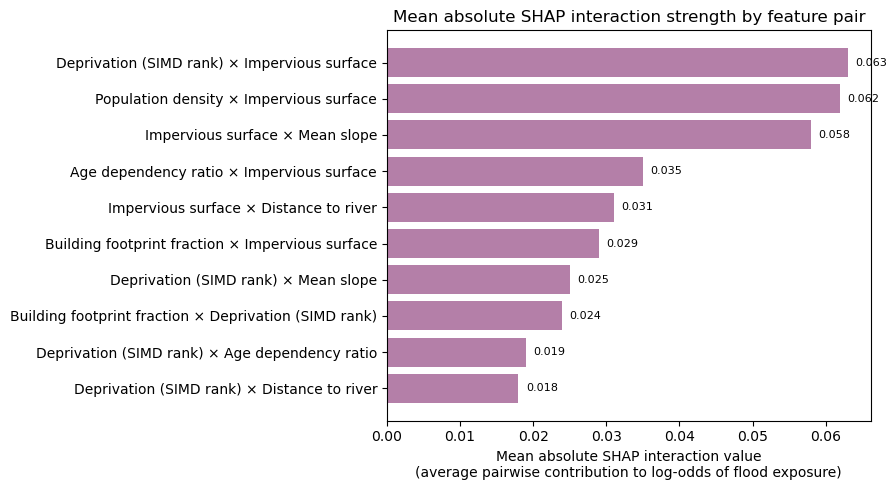

In [ ]:
import matplotlib.pyplot as plt

# Full variable names for each interaction pair
pairs_full = [
    "Deprivation (SIMD rank) × Impervious surface",
    "Population density × Impervious surface",
    "Impervious surface × Mean slope",
    "Age dependency ratio × Impervious surface",
    "Impervious surface × Distance to river",
    "Building footprint fraction × Impervious surface",
    "Deprivation (SIMD rank) × Mean slope",
    "Building footprint fraction × Deprivation (SIMD rank)",
    "Deprivation (SIMD rank) × Age dependency ratio",
    "Deprivation (SIMD rank) × Distance to river",
]

# Same mean |SHAP interaction| values as before
values = [0.063, 0.062, 0.058, 0.035, 0.031, 0.029, 0.025, 0.024, 0.019, 0.018]

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(pairs_full))

ax.barh(y, values, color="#b47fa8")
ax.set_yticks(y)
ax.set_yticklabels(pairs_full)
ax.invert_yaxis()

ax.set_xlabel(
    "Mean absolute SHAP interaction value\n"
    "(average pairwise contribution to log-odds of flood exposure)"
)
ax.set_title("Mean absolute SHAP interaction strength by feature pair")

# Numeric labels at the end of each bar
for i, v in enumerate(values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()



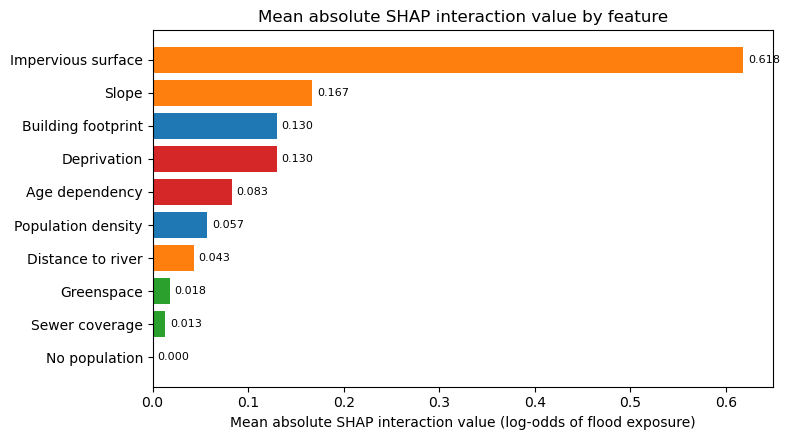

In [ ]:
import matplotlib.pyplot as plt

# Features and SHAP interaction values 
features = [
    "Impervious surface", "Slope", "Building footprint", "Deprivation",
    "Age dependency", "Population density", "Distance to river",
    "Greenspace", "Sewer coverage", "No population"
]
values = [0.618, 0.167, 0.130, 0.130, 0.083, 0.057, 0.043, 0.018, 0.013, 0.000]

# Colours by domain 
colors = [
    "tab:orange",  # Hazard
    "tab:orange",
    "tab:blue",    # Exposure
    "tab:red",     # Sensitivity
    "tab:red",
    "tab:blue",
    "tab:orange",
    "tab:green",   # Adaptive capacity
    "tab:green",
    "0.7"          # Other / data flag
]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = range(len(features))

ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(features)
ax.invert_yaxis()  # highest at top

# Axis labels and title
ax.set_xlabel("Mean absolute SHAP interaction value (log-odds of flood exposure)")
ax.set_title("Mean absolute SHAP interaction value by feature")

# Numeric labels at end of bars
for i, v in enumerate(values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


fig.savefig("shap_interaction_importance.png", dpi=300, bbox_inches="tight")

In [ ]:
# DIRECTION CHECK  (quantify sign of each feature's effect)

# For each feature, correlate the feature value with its SHAP value across hexes.
# Positive corr  -> high feature value pushes predicted exposure UP.
# Negative corr  -> high feature value pushes predicted exposure DOWN.
# Spearman is used (monotonic, robust to the non-linearity in the beeswarm).
from scipy.stats import spearmanr

log("\n--- SHAP direction check (feature value vs its SHAP value) ---")
log(f"  {'feature':<26}{'spearman_r':>11}{'share_pos_SHAP':>16}{'mean|SHAP|':>12}")
sv = pd.DataFrame(shap_vals, columns=FEATURES)
for fn in FEATURES:
    xv, s = X[fn].to_numpy(), sv[fn].to_numpy()
    mask = ~np.isnan(xv)                       # ignore NaN feature cells
    if mask.sum() < 10 or np.nanstd(xv[mask]) == 0:
        rho = np.nan
    else:
        rho, _ = spearmanr(xv[mask], s[mask])
    share_pos = float((s > 0).mean())          # fraction of hexes pushed upward
    direction = "high->UP" if (rho or 0) > 0 else "high->DOWN" if (rho or 0) < 0 else "flat"
    log(f"  {fn:<26}{rho:>11.3f}{share_pos:>16.3f}{np.abs(s).mean():>12.4f}  {direction}")


for fn in ["impervious_pct", "greenspace_frac"]:
    xv, s = X[fn].to_numpy(), sv[fn].to_numpy()
    mask = ~np.isnan(xv)
    hi = xv[mask] >= np.nanquantile(xv[mask], 0.90)      # top-decile (the "red" points)
    log(f"\n  [{fn}] top-decile (high-value) hexes:")
    log(f"    n={hi.sum()}   mean SHAP={s[mask][hi].mean():+.4f}   "
        f"max SHAP={s[mask][hi].max():+.4f}   "
        f"share with SHAP>0 = {(s[mask][hi] > 0).mean():.2f}")


--- SHAP direction check (feature value vs its SHAP value) ---
  feature                    spearman_r  share_pos_SHAP  mean|SHAP|
  pop_density                     0.709           0.228      0.0566  high->UP
  building_footprint_frac         0.776           0.268      0.1302  high->UP
  simd_rank                       0.711           0.480      0.1296  high->UP
  age_dep_ratio                   0.277           0.273      0.0831  high->UP
  greenspace_frac                 0.521           0.101      0.0184  high->UP
  sewer_catchment_coverage        0.577           0.193      0.0134  high->UP
  impervious_pct                  0.772           0.196      0.6180  high->UP
  mean_slope                     -0.957           0.403      0.1667  high->DOWN
  dist_to_river_m                -0.437           0.487      0.0428  high->DOWN
  no_population                     nan           0.000      0.0000  flat

  [impervious_pct] top-decile (high-value) hexes:
    n=420   mean SHAP=+1.2495   max S

<positron-console-cell-8>:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


In [14]:
import numpy as np
import geopandas as gpd
from pathlib import Path

HEX_PATH = Path("hex_clean_sepa.gpkg")
df = gpd.read_file(HEX_PATH)

# Create the missing S1 log-response the same way SEPA's was made.
# log1p is safe for zeros; if log_sepa_flood_frac used plain log on a floored
# value, replicate THAT instead so the two are consistent (see note below).
if "log_s1_flood_frac" not in df.columns:
    df["log_s1_flood_frac"] = np.log1p(df["s1_flood_frac"])

# Standardised predictors are the *_z columns (mean~0, std~1) — these match the OLS fit
PREDICTORS = [
    "greenspace_frac_z", "sewer_catchment_coverage_z",
    "sqrt_impervious_pct_z", "sqrt_mean_slope_z", "sqrt_dist_to_river_m_z",
]
RESPONSES = ["log_s1_flood_frac", "log_sepa_flood_frac"]
VARS = PREDICTORS + RESPONSES
COLS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]

#  Descriptive-statistics table

In [ ]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

HEX_PATH = Path("hex_clean_sepa.gpkg")
df = gpd.read_file(HEX_PATH)

# Create the missing S1 log-response the same way SEPA's was made.

if "log_s1_flood_frac" not in df.columns:
    df["log_s1_flood_frac"] = np.log1p(df["s1_flood_frac"])

# Standardised predictors are the *_z columns (mean~0, std~1) — match the OLS fit
PREDICTORS = [
    "greenspace_frac_z", "sewer_catchment_coverage_z",
    "sqrt_impervious_pct_z", "sqrt_mean_slope_z", "sqrt_dist_to_river_m_z",
]
RESPONSES = ["log_s1_flood_frac", "log_sepa_flood_frac"]
VARS = PREDICTORS + RESPONSES
COLS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]

missing = [v for v in VARS if v not in df.columns]
if missing:
    raise KeyError(f"These variables are not in the data: {missing}\n"
                   f"Available columns: {list(df.columns)}")

# Describe (force correct column order; describe() is per-column,
#    so quartiles are computed independently and are ALWAYS ordered)

desc = df[VARS].describe().T          # rows = variables, cols = stats
desc = desc[COLS]                     # enforce canonical column order
desc = desc.round(4)
print("\n=== Descriptive statistics ===")
print(desc.to_string())

# Validate 
problems = []

# Quartile monotonicity: min <= 25% <= 50% <= 75% <= max
order = ["min", "25%", "50%", "75%", "max"]
for v in desc.index:
    seq = desc.loc[v, order].to_numpy(dtype=float)
    if not np.all(np.diff(seq) >= -1e-9):     # tiny tolerance for float noise
        problems.append(f"[{v}] order statistics not non-decreasing: "
                        f"{dict(zip(order, seq))}")

#  std must be non-negative
for v in desc.index:
    if desc.loc[v, "std"] < 0:
        problems.append(f"[{v}] negative std = {desc.loc[v,'std']}")

# standardised predictors should have mean ~ 0 and std ~ 1
for v in PREDICTORS:
    if abs(desc.loc[v, "mean"]) > 0.01:
        problems.append(f"[{v}] mean not ~0 ({desc.loc[v,'mean']}) "
                        f"-> is it actually standardised?")
    if abs(desc.loc[v, "std"] - 1.0) > 0.05:
        problems.append(f"[{v}] std not ~1 ({desc.loc[v,'std']}) "
                        f"-> is it actually standardised?")

print("\n=== Validation ===")
if problems:
    print("PROBLEMS FOUND:")
    for p in problems:
        print("  -", p)
else:
    print("OK: all rows have ordered quartiles, non-negative std, "
          "and predictors are properly standardised.")


out = desc.copy()
out["mean"] = [f"{m:.2e}" if v in PREDICTORS else f"{m:.4f}"
               for v, m in zip(out.index, out["mean"])]
out.to_csv("descriptive_stats_clean.csv")
print("\nSaved -> descriptive_stats_clean.csv")
print(out.to_string())


=== Descriptive statistics ===
                             count    mean     std      min     25%     50%     75%     max
greenspace_frac_z           3276.0  0.0000  1.0002  -0.2022 -0.2022 -0.2022 -0.2022  9.9108
sewer_catchment_coverage_z  3276.0  0.0000  1.0002  -0.4193 -0.4193 -0.4193 -0.4193  3.0940
sqrt_impervious_pct_z       3276.0 -0.0000  1.0002  -0.5218 -0.5218 -0.5218  0.0311  4.4361
sqrt_mean_slope_z           3276.0 -0.0000  1.0002  -2.5305 -0.7144 -0.1530  0.6082  3.8527
sqrt_dist_to_river_m_z      3276.0  0.0000  1.0002  -1.9945 -0.7578 -0.0823  0.6535  3.6381
log_s1_flood_frac           3276.0  0.0025  0.0132   0.0000  0.0000  0.0000  0.0000  0.3051
log_sepa_flood_frac         3276.0 -4.3479  1.7188 -16.5640 -5.3416 -4.1735 -3.2116 -0.0055

=== Validation ===
OK: all rows have ordered quartiles, non-negative std, and predictors are properly standardised.

Saved -> descriptive_stats_clean.csv
                             count       mean     std      min     25%     50

# Descriptive-statistics table 
Uses ORIGINAL (unstandardised) variables.

In [ ]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path


HEX_PATH = Path("hex_clean_sepa.gpkg")
df = gpd.read_file(HEX_PATH)

# Build the S1 log-response to match how log_sepa_flood_frac was made.
if "log_s1_flood_frac" not in df.columns:
    df["log_s1_flood_frac"] = np.log1p(df["s1_flood_frac"])

# ORIGINAL (unstandardised) modelled predictors: sqrt where transformed, raw otherwise
PREDICTORS = [
    "greenspace_frac", "sewer_catchment_coverage",
    "sqrt_impervious_pct", "sqrt_mean_slope", "sqrt_dist_to_river_m",
]
RESPONSES = ["log_s1_flood_frac", "log_sepa_flood_frac"]
VARS = PREDICTORS + RESPONSES
COLS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]

missing = [v for v in VARS if v not in df.columns]
if missing:
    raise KeyError(f"These variables are not in the data: {missing}\n"
                   f"Available columns: {list(df.columns)}")

# (describe() is per-column, so quartiles are always ordered)

desc = df[VARS].describe().T          # rows = variables, cols = stats
desc = desc[COLS]                     # enforce canonical column order
desc = desc.round(4)
print("\n=== Descriptive statistics ===")
print(desc.to_string())

# Validate 
problems = []

# Quartile monotonicity: min <= 25% <= 50% <= 75% <= max
order = ["min", "25%", "50%", "75%", "max"]
for v in desc.index:
    seq = desc.loc[v, order].to_numpy(dtype=float)
    if not np.all(np.diff(seq) >= -1e-9):     # tiny tolerance for float noise
        problems.append(f"[{v}] order statistics not non-decreasing: "
                        f"{dict(zip(order, seq))}")

# std must be non-negative
for v in desc.index:
    if desc.loc[v, "std"] < 0:
        problems.append(f"[{v}] negative std = {desc.loc[v,'std']}")

# (variables are UNSTANDARDISED here, so no mean~0 / std~1 check)

print("\n=== Validation ===")
if problems:
    print("PROBLEMS FOUND:")
    for p in problems:
        print("  -", p)
else:
    print("OK: all rows have ordered quartiles and non-negative std.")


out = desc.round(4)
out.to_csv("descriptive_stats_clean.csv")
print("\nSaved -> descriptive_stats_clean.csv")
print(out.to_string())


=== Descriptive statistics ===
                           count     mean     std      min      25%      50%      75%      max
greenspace_frac           3276.0   0.0200  0.0989   0.0000   0.0000   0.0000   0.0000   1.0000
sewer_catchment_coverage  3276.0   0.1194  0.2847   0.0000   0.0000   0.0000   0.0000   1.0000
sqrt_impervious_pct       3276.0   1.0414  1.9959   0.0000   0.0000   0.0000   1.1034   9.8938
sqrt_mean_slope           3276.0   2.6516  0.7809   0.6758   2.0938   2.5321   3.1264   5.6598
sqrt_dist_to_river_m      3276.0  17.9181  8.8094   0.3508  11.2432  17.1936  23.6740  49.9627
log_s1_flood_frac         3276.0   0.0025  0.0132   0.0000   0.0000   0.0000   0.0000   0.3051
log_sepa_flood_frac       3276.0  -4.3479  1.7188 -16.5640  -5.3416  -4.1735  -3.2116  -0.0055

=== Validation ===
OK: all rows have ordered quartiles and non-negative std.

Saved -> descriptive_stats_clean.csv
                           count     mean     std      min      25%      50%      75%      m